In [1]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
import unidecode
import matplotlib.pyplot as plt
import re

sw = stopwords.words("spanish")
snow = SnowballStemmer('spanish')

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
class Word2VecFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, vector_size=100, window=5, min_count=1, sg=0):
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.sg = sg
        self.model = None

    def fit(self, X, y=None):
        X = [sentence.split() for sentence in X]
        self.model = Word2Vec(sentences=X, vector_size=self.vector_size, window=self.window, min_count=self.min_count, sg=self.sg,epochs=30)
        return self

    def transform(self, X):
        feature_vectors = []
        for text in X:
            vectors = [self.model.wv[word] for word in text if word in self.model.wv]
            feature_vectors.append(np.mean(vectors, axis=0))
           
        return np.array(feature_vectors)

def limpiar(text):
    return ' '.join([snow.stem(unidecode.unidecode(w)) for w in re.findall(r'[a-záéíóúñ]+',str(text).lower()) if (len(w)>=2) and (w not in sw)])

In [4]:
data = pd.read_excel('80s.xlsx')
data['Comentariomin'] = data['Comentariomin'].apply(limpiar)
data = pd.concat([data[data.EVALUACION==1],data[data.EVALUACION==5].sample(889,ignore_index=True),data[data.EVALUACION==3].sample(889,ignore_index=True)])

In [5]:
from sklearn.ensemble import GradientBoostingClassifier  
from sklearn.ensemble import RandomForestClassifier   
from sklearn.ensemble import ExtraTreesClassifier    
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier    
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.svm import SVC

In [15]:
pipelines = []
for name_1, vectorizer in [('tf',TfidfVectorizer(use_idf=False)),('tf',TfidfVectorizer(use_idf=True)),('w2v',Word2VecFeatureExtractor())]:
    sequences = []
    for name_2, model in [('gradientboosting',GradientBoostingClassifier()),('rf',RandomForestClassifier()),('extratrees',ExtraTreesClassifier()),('lr',LogisticRegression()),('dt',DecisionTreeClassifier()),('knn',KNeighborsClassifier()),('svm',SVC()),('mlp',MLPClassifier())]:
        sequences.append(Pipeline([(name_1,vectorizer),(name_2,model)]))
    pipelines.append(sequences)

In [7]:
vector_params = {
    'tf': {
        'max_features': [20, 50, 100, 200, None],
        'ngram_range': [(1, 1), (1, 2), (1, 3)],
        'norm': ['l1', 'l2', None],
        'max_df': [0.75, 0.85]
    },
    'w2v': {
        'vector_size': [20, 50, 100, 200, 500],
        'window': [3, 5],
        'min_count': [5, 10],
        'sg': [0, 1]
    }
}

model_params = {
    "gradientboosting": {
        'n_estimators': [50, 100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
        'max_depth': [None, 10, 20, 30, 50, 100],
        'subsample': [0.6, 0.8, 1.0],
        'min_samples_split': [2, 5, 10, 30, 50],
        'min_samples_leaf': [1, 2, 4, 8, 15, 30, 50],
        'max_features': ['sqrt', 'log2', None]
    },
    "rf": {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [None, 10, 20, 30, 50, 100],
        'min_samples_split': [2, 5, 10, 30, 50],
        'min_samples_leaf': [1, 2, 4, 8, 15, 30, 50],
        'max_features': ['sqrt', 'log2', None],
        'bootstrap': [True, False]
    },
    "extratrees": {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [None, 10, 20, 30, 50, 100],
        'min_samples_split': [2, 5, 10, 30, 50],
        'min_samples_leaf': [1, 2, 4, 8, 15, 30, 50],
        'max_features': ['sqrt', 'log2', None],
        'bootstrap': [True, False]
    },
    "lr": {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'lbfgs', 'saga'],
        'penalty': ['l1', 'l2', 'elasticnet', None],
        'max_iter': [100, 200, 500, 1000]
    },
    "dt": {
        'criterion': ['gini', 'entropy', 'log_loss'],
        'max_depth': [None, 10, 20, 30, 50, 100],
        'min_samples_split': [2, 5, 10, 30, 50],
        'min_samples_leaf': [1, 2, 4, 8, 15, 30, 50],
        'max_features': ['sqrt', 'log2', None]
    },
    "knn": {
        'n_neighbors': [3, 5, 10, 20],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski'],
        'p': [1, 2]
    },
    "svm": {
        'C': [0.1, 1, 10, 100],
        'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
        'degree': [2, 3, 4],
        'gamma': ['scale', 'auto'],
        'shrinking': [True, False]
    },
    "mlp": {
        "hidden_layer_sizes": [(50,), (100,), (50, 50), (100, 100)],
        "activation": ["tanh", "relu"],
        "solver": ["adam", "sgd"],
        "alpha": [0.0001, 0.001, 0.01],
        "learning_rate": ["constant", "adaptive"],
        "learning_rate_init": [0.001, 0.01],
        "max_iter": [200, 500],
        "batch_size": ["auto", 64, 128]
    }
}

x = {}
x.update(vector_params)
x.update(model_params)

params = {}
for key, embeds in x.items():
    for subkey, distribs in embeds.items():
        params.update({f'{key}__{subkey}':distribs})

def get_distrib(pipe):
    tmp_dict = {}
    for key, values in params.items():
        if key in pipe.get_params().keys():
            tmp_dict.update({key:values})
    return tmp_dict

In [8]:
X_T, X_t, Y_T, Y_t = train_test_split(data.Comentariomin,data.EVALUACION,test_size=0.2,random_state=42,shuffle=True,stratify=data.EVALUACION)

In [9]:
def training(pipe):
    kfold = KFold(n_splits=10, random_state=42, shuffle= True)
    T_results = []
    t_results = []
    hyperparams = []
    for subpipe in pipe:
         print(f'Training {list(subpipe.named_steps.keys())}')
         subparams = get_distrib(subpipe)
         rs = RandomizedSearchCV(
             subpipe,
             param_distributions=subparams,
             n_iter=30,
             scoring='accuracy',
             cv=5
         )
         rs.fit(X_T,Y_T)
         best = rs.best_estimator_
         
         train_acc = cross_val_score(best,X_T,Y_T,cv=kfold,scoring='accuracy')
         test_acc = accuracy_score(Y_t,best.predict(X_t))
         best_params = rs.best_params_
         
         T_results.append(train_acc)
         t_results.append(test_acc)
         hyperparams.append(best_params)
         
         print(f"""Best hyperparameters: {best_params}
Train Acc: {train_acc.mean():.4f} ({train_acc.std():.4f})
Test Acc: {test_acc}\n""")
         
    return T_results, t_results, hyperparams

def compute_boxes(T_results, t_results, title):
    models = ['gradientboosting','rf','extratrees','lr','dt','knn','svm','mlp']
    labels = [f"{tag}\n({t_results[i]*100:.2f}%)" for i,tag in enumerate(models)]
    
    fig = plt.figure(figsize=[10,7])
    fig.suptitle(title)
    ax = fig.add_subplot(111)
    plt.boxplot(T_results)
    ax.set_xticklabels(labels)
    plt.show()

### Term Frequency, Inverse Document Frequency

Training ['tf', 'gradientboosting']
Best hyperparameters: {'tf__norm': 'l1', 'tf__ngram_range': (1, 1), 'tf__max_features': 100, 'tf__max_df': 0.75, 'gradientboosting__subsample': 0.6, 'gradientboosting__n_estimators': 200, 'gradientboosting__min_samples_split': 50, 'gradientboosting__min_samples_leaf': 4, 'gradientboosting__max_features': 'log2', 'gradientboosting__max_depth': 100, 'gradientboosting__learning_rate': 0.01}
Train Acc: 0.7398 (0.0320)
Test Acc: 0.7134831460674157

Training ['tf', 'rf']
Best hyperparameters: {'tf__norm': None, 'tf__ngram_range': (1, 3), 'tf__max_features': 200, 'tf__max_df': 0.85, 'rf__n_estimators': 300, 'rf__min_samples_split': 10, 'rf__min_samples_leaf': 4, 'rf__max_features': 'sqrt', 'rf__max_depth': 20, 'rf__bootstrap': False}
Train Acc: 0.7346 (0.0309)
Test Acc: 0.7359550561797753

Training ['tf', 'extratrees']
Best hyperparameters: {'tf__norm': 'l1', 'tf__ngram_range': (1, 1), 'tf__max_features': 200, 'tf__max_df': 0.75, 'extratrees__n_estimators':

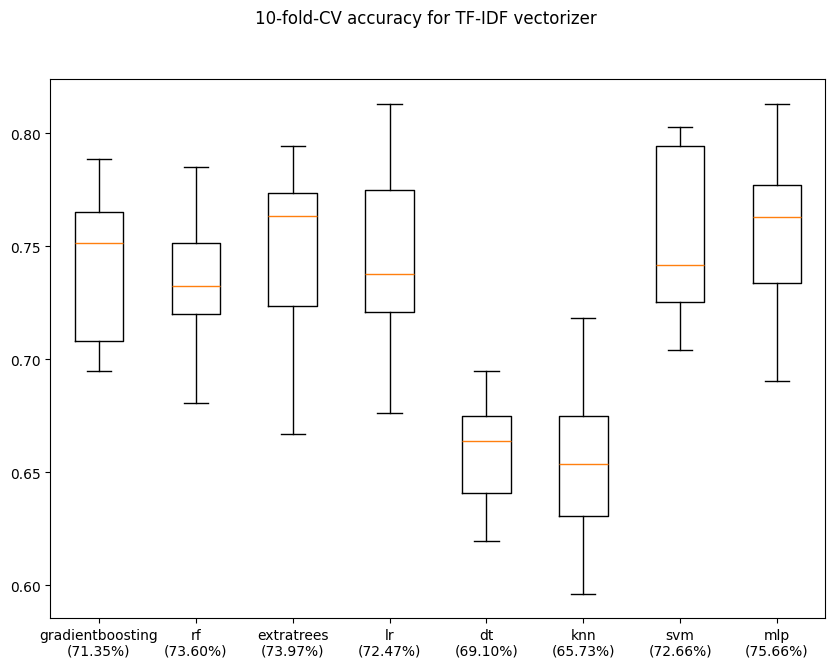

In [ ]:
tfidf = pipelines[1]
T_results, t_results, hyperparams = training(tfidf)
compute_boxes(T_results,t_results,'10-fold-CV accuracy for TF-IDF vectorizer')

### Estandarizando

Training ['tf', 'scaler', 'gradientboosting']
Best hyperparameters: {'tf__norm': None, 'tf__ngram_range': (1, 2), 'tf__max_features': None, 'tf__max_df': 0.85, 'gradientboosting__subsample': 1.0, 'gradientboosting__n_estimators': 100, 'gradientboosting__min_samples_split': 10, 'gradientboosting__min_samples_leaf': 1, 'gradientboosting__max_features': 'sqrt', 'gradientboosting__max_depth': 20, 'gradientboosting__learning_rate': 0.05}
Train Acc: 0.7651 (0.0367)
Test Acc: 0.7602996254681648

Training ['tf', 'scaler', 'rf']
Best hyperparameters: {'tf__norm': None, 'tf__ngram_range': (1, 1), 'tf__max_features': None, 'tf__max_df': 0.75, 'rf__n_estimators': 300, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 2, 'rf__max_features': 'sqrt', 'rf__max_depth': 30, 'rf__bootstrap': True}
Train Acc: 0.7468 (0.0345)
Test Acc: 0.7172284644194756

Training ['tf', 'scaler', 'extratrees']
Best hyperparameters: {'tf__norm': None, 'tf__ngram_range': (1, 1), 'tf__max_features': None, 'tf__max_df': 0.7

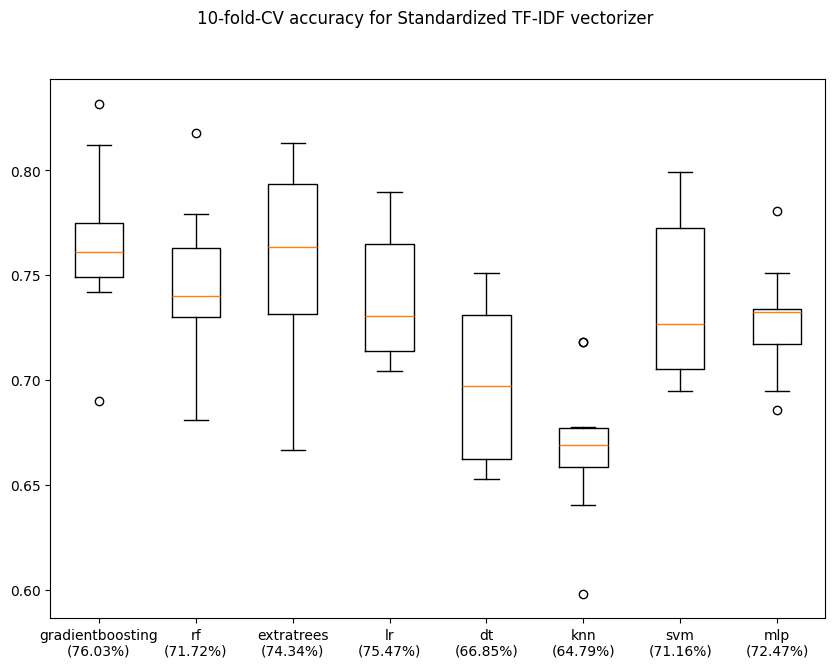

In [12]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
std_tfidf = pipelines[0]

for i,pipe in enumerate(std_tfidf):
    steps = pipe.steps
    steps.insert(1,('scaler',StandardScaler(with_mean=False)))
    std_tfidf[i].steps = steps

T_results_std, t_results_std, hyperparams_std = training(std_tfidf)
compute_boxes(T_results_std,t_results_std,'10-fold-CV accuracy for Standardized TF-IDF vectorizer')